# Data Preparation

The rest of this page depends on the successful loading of the CSV data into df. Therefore, whenever you open or reconnect to this page, it is important to always **run this code block first** before working on the other code blocks of the page.

In [1]:
import pandas as pd
# set float display format to comma as thousand separator and 2 digits after the decimal point
pd.options.display.float_format = '{:,.2f}'.format

# Collect data from a CSV file
df = pd.read_csv('https://raw.githubusercontent.com/qarnac/cs201/refs/heads/main/insured_by_states_18_64.csv')

df.columns

Index(['State', 'All_Percent', 'All_People', 'White_Percent', 'White_People',
       'Black_Percent', 'Black_People', 'AI_AN_Percent', 'AI_AN_People',
       'API_Percent', 'API_People', 'Hispanic_Percent', 'Hispanic_People'],
      dtype='object')

# The matplotlib Library

Descriptive statistics are helpful to provide a high level overview of the data. Data scientists often use **data visualization** to gain additional insights about the data.

The [matplotlib library](https://matplotlib.org/) supports functions for creating static, animated, and interative visualizations. It is a third-party library. Fortunately, Google Colab already includes this library in its environment. If you are running Python in an environment that does not already support this library, you will need to run the following to install it.

In [ ]:
!pip install matplotlib
#Do not run this block since Google Colab already supports both numpy and matplotlib

The `matplotlib` is a huge library that include several sub-libraries/modules in it. The main module we will be using from `matplotlib` is `pyplot`. It is important and a common practice for developers to include the following `import` statement before plotting their graphs. This statement also helps developers to use `plt` as the abbreviation of `pyplot` when calling functions from the `pyplot` library.

In [ ]:
import matplotlib.pyplot as plt

# Bar charts

Bar charts are one of the most common and effective ways to visualize data. They are intuitive and easy to read.

In a bar chart:
- Each **bar** represents a category.
- The **height** of the bar shows the value associated with that category.
- Bars can be grouped or stacked to show comparisons across multiple variables.

The pandas' `plot` function is built on top of `matplotlib` and supports many parameters to specify details of a graph generated by matplotlit.

For example, the following code block shows how to use the plot function to set up a bar chart:

*  The `kind` parameter is set to `'bar'`, indicating a **bar chart** is to be created.
*  The `x` parameter indicates the column from which the values for the **x-axis** will be drawn. It is set to the `'State'` column.
*  The `y` parameter indicates the column from which the values for the y-axis will be drawn. It is set to the `'All_Percent'` column.
*  The `figsize` parameter helps set the figure size as in `plt.figure` function.


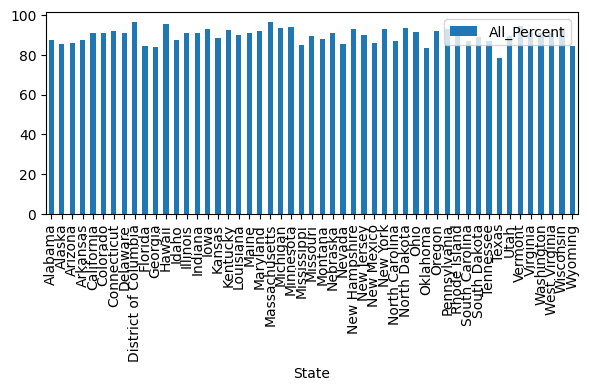

In [23]:
import matplotlib.pyplot as plt     # import appropriate library

# create the bar chart before adjusting title and others
df.plot(kind='bar',       #The kind attribute specify the type of graph
        x='State',        # The x attribute specifies a categorical column
        y='All_Percent',  # The y attribute identifies a numeric column
        figsize=(6, 4)    # The pair specifies the width and height of the graph
        )

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart

The above bar chart is quite busy/crowded there are 51 rows in the DataFrame. We can use row filtering to create DataFrame objects of less rows.

For example, the following code block first create a DataFrame object that focuses on states whose coverage for all races combined is higher than 90%.

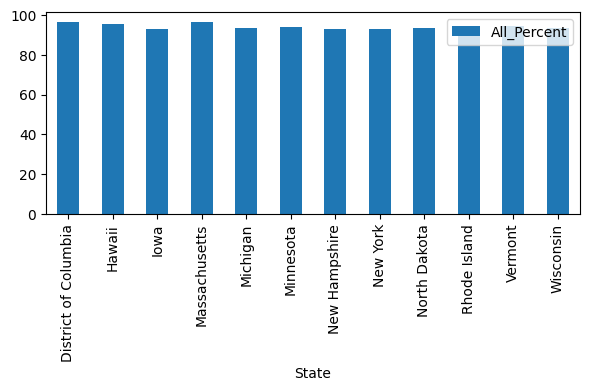

In [24]:
import matplotlib.pyplot as plt     # import appropriate library

# Apply row filtering to create a new DataFrame object with less rows
condition = df['All_Percent'] >= 93
high_coverage_df = df[condition]

# create the bar chart before adjusting title and others
high_coverage_df.plot(kind='bar', x='State', y='All_Percent', figsize=(6, 4))

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart

The following code block creates a new DataFrame by choosing some states by name.

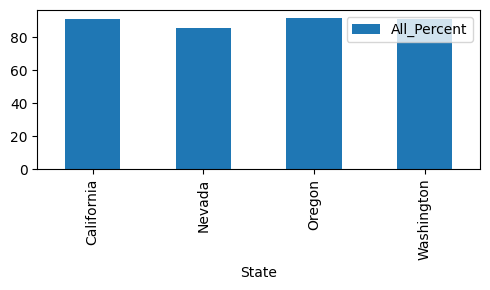

In [25]:
import matplotlib.pyplot as plt     # import appropriate library

# Apply row filtering to create a new DataFrame object with less rows
condition = df['State'].isin(['California', 'Oregon', 'Washington', 'Nevada'])
selected_states_df = df[condition]

# create the bar chart before adjusting title and others
selected_states_df.plot(kind='bar', x='State', y='All_Percent', figsize=(5, 3))

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart

The above bar chart helps visualize a few things:

*  All four states have higher than 80% insurance coverage.
* Oregon has the highest coverage among the four states.
*  Nevada has the lowest coverage among the four states.

There are additional parameters we can specify for the `plot` function.

*  The title parameter specifies the title for the graph.
*  The xlabel and ylabels parameters specify the labels to be put on the respective axis.
*  The rot parameter specifies rotation of x-tick labels.

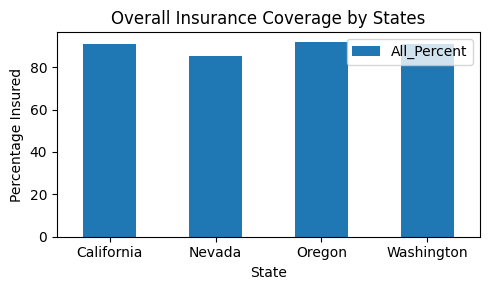

In [26]:
import matplotlib.pyplot as plt     # import appropriate library

# create the bar chart
selected_states_df.plot(kind='bar',       # to create a bar chart
              x='State',          # the column whose values will be used for the x-axis
              y='All_Percent',    # the column whose values will be used for the y-axis
              figsize=(5, 3),     # 600 pixels for the width, 400 pixels for the height
              title='Overall Insurance Coverage by States',     # title of the graph
              ylabel='Percentage Insured',              # label for the y-axis
              rot=0             # Rotation of the x-ticks values
)

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart


The plot function also allows the y parameter to include multiple columns as shown in the following code block.

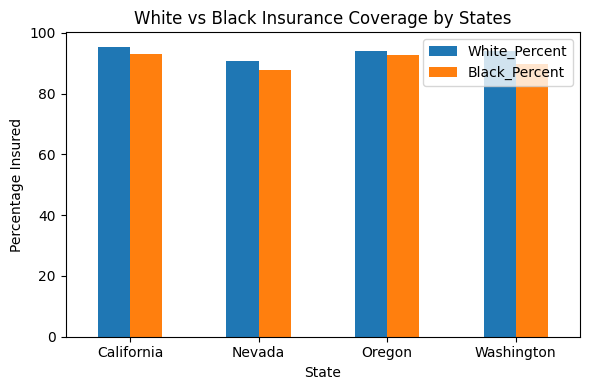

In [27]:
# create the bar chart
import matplotlib.pyplot as plt
selected_states_df.plot(kind='bar',
                        x='State',
                        y=['White_Percent', 'Black_Percent'],
                        figsize=(6, 4),
                        title='White vs Black Insurance Coverage by States',
                        ylabel='Percentage Insured',
                        rot=0
)

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart


The above bar chart helps visualize a few things:

*  In all four states, insurance coverage for white is better than black.
*  The gaps is the smallest in Oregon and largest in Washington.

### Practice

In [31]:
df.describe()

,All_Percent,All_People,White_Percent,White_People,Black_Percent,Black_People,AI_AN_Percent,AI_AN_People,API_Percent,API_People,Hispanic_Percent,Hispanic_People
count,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00
mean,89.90,"3,447,982.47",92.64,"2,060,351.25",88.58,"419,555.27",84.70,"16,408.20",92.07,"238,174.63",76.50,"602,070.04"
std,3.77,"3,915,733.08",2.81,"1,764,780.26",3.90,"503,924.22",6.57,"21,424.52",2.93,"535,982.29",7.61,"1,380,580.42"
min,78.40,"282,570.00",87.00,"166,705.00",78.40,"2,742.00",67.20,562.00,85.00,"3,542.00",61.60,"8,848.00"
25%,87.15,"950,184.50",90.55,"732,739.50",86.00,"35,048.50",81.75,"4,973.00",90.05,"26,341.00",72.80,"85,205.00"
50%,91.00,"2,344,505.00",93.20,"1,634,873.00",89.00,"190,036.00",86.00,"8,645.00",92.50,"82,972.00",76.30,"187,993.00"
75%,92.65,"4,216,251.00",94.70,"2,791,316.50",90.95,"681,280.00",89.05,"19,589.50",94.05,"237,468.50",81.15,"456,638.00"
max,96.50,"21,646,886.00",98.10,"7,454,149.00",95.80,"1,864,406.00",95.40,"101,187.00",97.60,"3,634,108.00",92.10,"8,352,387.00"


In [ ]:
# Data preparation: Create a new DataFrame object from df using a filtering condition of your choice
# For example, focus on rows with percentage coverage for a race in a given range


In [ ]:
# Create a bar chart to compare insurance coverage for one column of your choice among the states in your new dataset.


In [ ]:
# Create a bar chart to compare insurance converage for multiple columns of your choice among the states in your new dataset.


**Add a text block** to communicate key observations from the above bar charts.

Among the states of your new DataFrame,

*  Which state has the highest coverage?
*  Which state has the lowest coverage?
*  Which state has the most difference between multiple columns of your choice?
*  Which state has the least difference between multiple columns of your choice?
*  Are you surprised by the data? Or do the data align with your expectation?

# Histograms

A **histogram** is a graph that shows how many values fall into different ranges (called bins). Let's look at a few examples to understand how histograms help show data distributions.

The `plot` function we used for bar charts can also be used to create a histogram as shown in the following code block.

*  We only need to identify the column for the y-axis.
*  There is no column for the x axis. By default, the `plot` function divides up the range of the numeric column into 10 equal smaller ranges (bins). Since the highest percent for all races is 96.50 and the lowest is 78.40, the overall range is 18.10. One-tenth of the range is 1.81 and the bins have the following ranges,

    *  Frst bin: 78.40 to 80.21
    *  Second bin: 80.21 to 82.02
    *  And so on so forth
*  The height of each bar tells how many states fall into the range for that bin. In this way, a histogram can help us see patterns:
    *  Is it symmetric, left-skewed, right-skewed, bimodal…?
    *  Are there outliers?

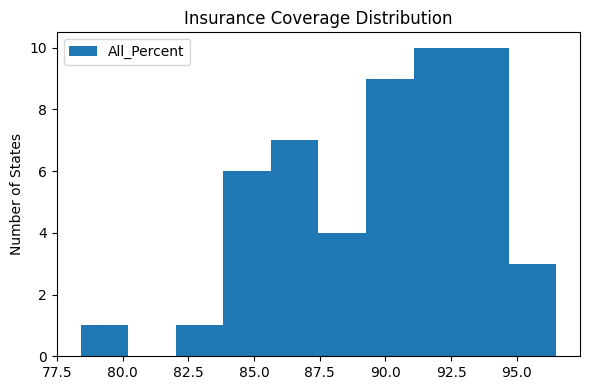

In [28]:
import matplotlib.pyplot as plt     # import appropriate library

# create the bar chart
df.plot(kind='hist',        # note the kind is hist, short for histogram
        y='All_Percent',    # identify a numeric column to be analyzed
        figsize=(6, 4),     # 600 pixel wide and 400 pixel tall
        title='Insurance Coverage Distribution',
        ylabel='Number of States'
)

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart

The above histogram shows the following
*  Only one state has coverage percentage below 80.21, possibly an outlier compared to other states.
*  There are 6 states whose coverage percentage belong to the fourth bin (83.83 to 85.64), 7 states for the fifth bin (85.64 to 87.45), etc.
*  The distribution is right skewed, i.e. heavier on the bins for larger percentages.

There are additional parameters for the plot function we can adjust.
*  The `bins` parameter specifies the number of bins to be used.
*  The `range` parameter specifies the lower and upper bounds of the bins.
*  The `color` parameter specifies the color of the bars.
*  The `edgecolor` parameter specifies the color of the edges for the bars.
*  The `alpha` parameter specifies the level of transparency for the bars. 0 is fully transparent and 1 is fully opaque.
*  The `legend` parameter indicates whether to show the legend of the graph.


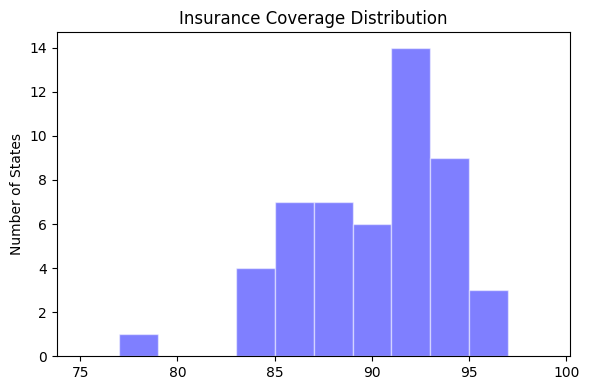

In [29]:
import matplotlib.pyplot as plt     # import appropriate library

# create the bar chart
df.plot(kind='hist',
        y='All_Percent',
        figsize=(6, 4),
        title='Insurance Coverage Distribution',
        ylabel='Number of States',
        bins=12,              # The number of bins to be used for counting
        range=(75, 99),       # Smallest value is 75, largest value is 99
        color='blue',         # color of the bars
        edgecolor='white',    # color of the edges
        alpha=0.5,            # transparency of the bars
        legend=False
)

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart

The following code block shows the distribution of coverage for states whose number of people insured are between 1 and 10 million.

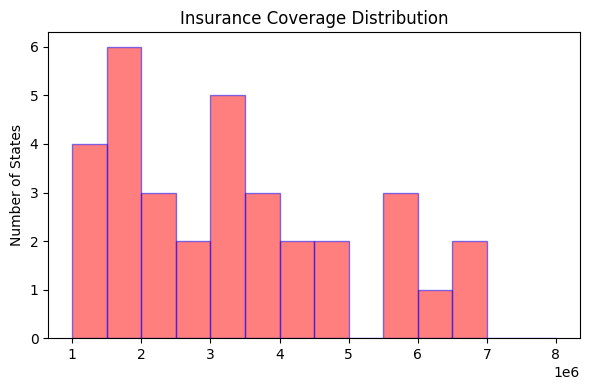

In [30]:
import matplotlib.pyplot as plt     # import appropriate library

# create the bar chart
df.plot(kind='hist',
        y='All_People',
        figsize=(6, 4),
        title='Insurance Coverage Distribution',
        ylabel='Number of States',
        bins=14,
        range=(1000000, 8000000),
        color='red',
        edgecolor='blue',
        alpha=0.5,
        legend=False
)

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart

The above histograph shows that there are
*  4 states whose insurance coverage for all races are between 1 and 1.5 million, including 1 million but excluding 1.5 million.
*  6 states whose insurance coverage for all races are between 1.5 and 2 million, including 1.5 million but excluding 2 million.
*  3 states for between 2 and 2.5, etc.

The bins for these histograms are left inclusive and right exclusive.

## Practice

In [ ]:
# Create a histogram for the percentage coverage for the race of your choice


In [ ]:
# Create a histogram for the population for the race of your choice


Add a **Markdown text block** to explain what you learn about the insurance coverage and population for the race of your choice through the above histogram.

For each histogram:

*  What are the boundary values for the leftmost bin? How many states fall into it?
*  What are the boundary values for the rightmost bin? How many states fall into it?
*  Pick one bin that is the tallest. What are the boundary values for the bin? How many states fall in that bin?
*  Pick one bin that is the shortest. What are the boundary values for the bin? How many states fall in that bin?